  ✅ All libraries loaded. Ready to go!

  DATASET OVERVIEW

  Shape   : 1000 rows × 8 columns

  Columns : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

  Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

  Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

  Duplicates: 0

  First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female       

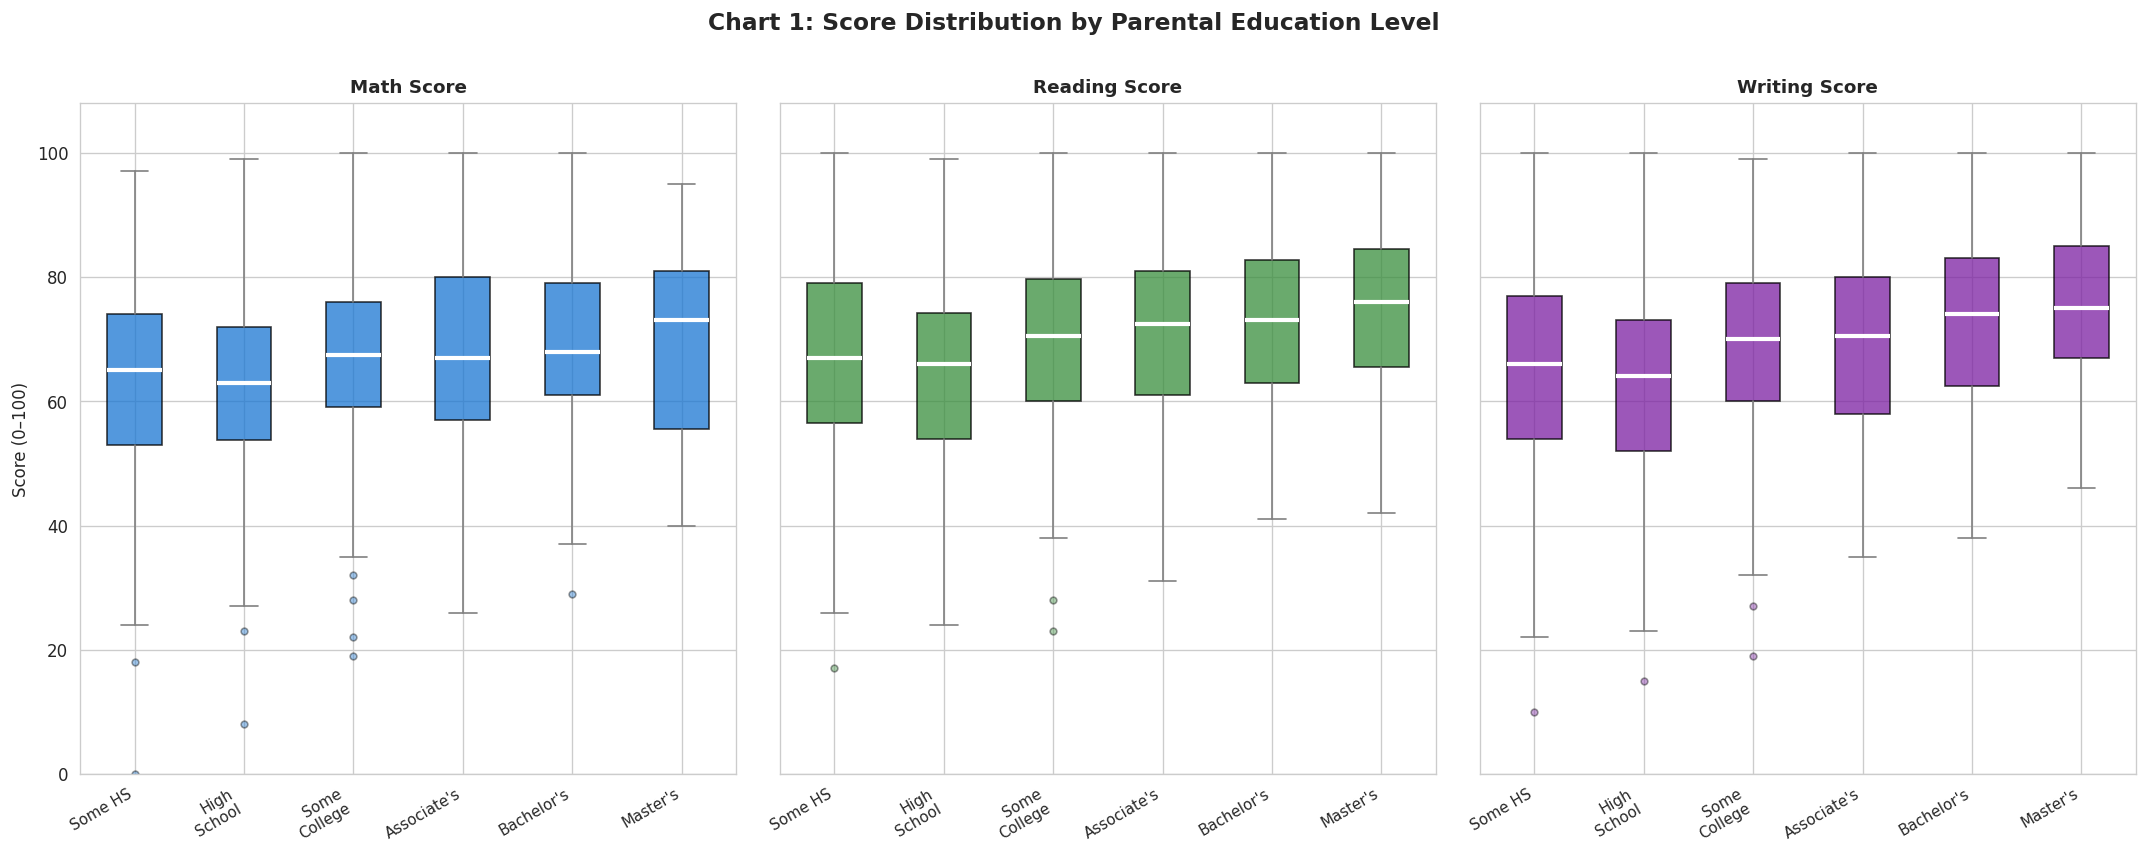

  ✅ Chart 1 done


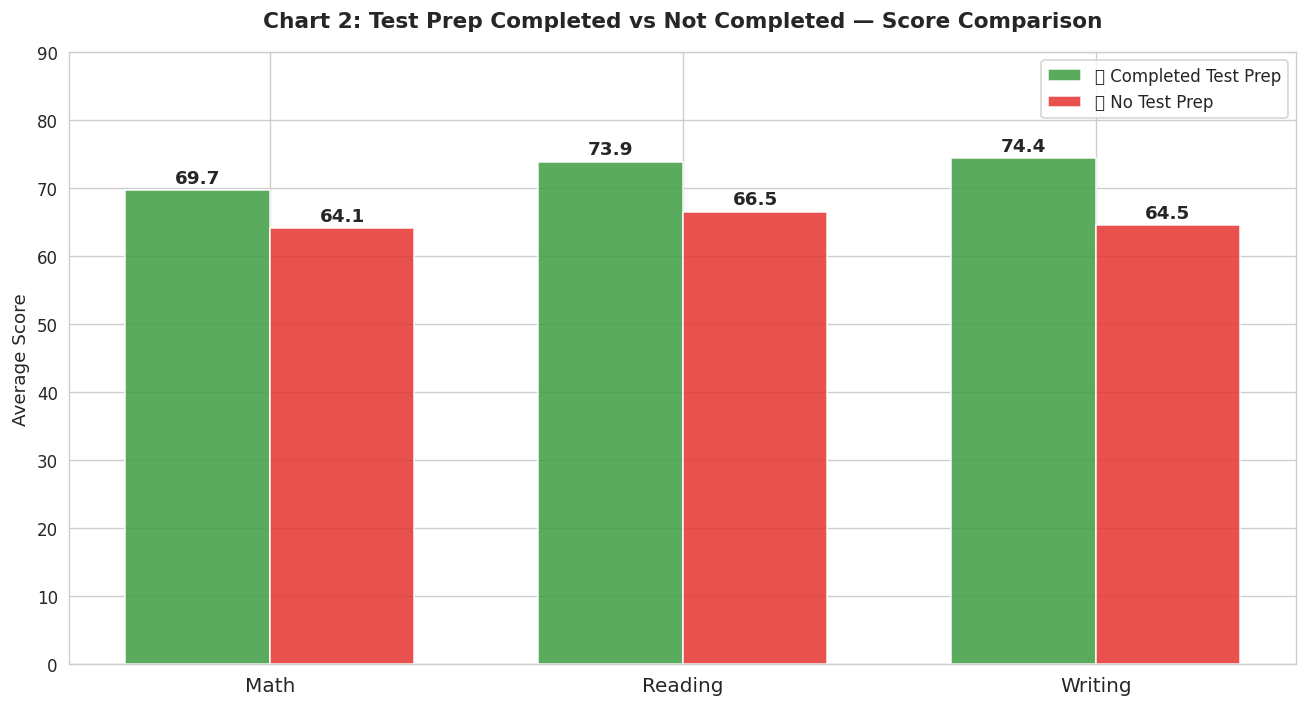

  ✅ Chart 2 done


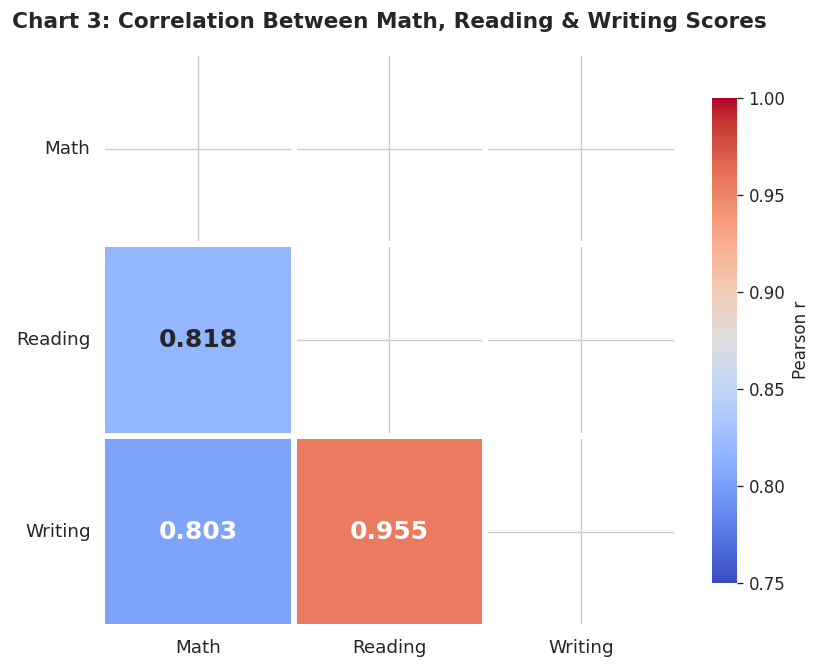

  ✅ Chart 3 done


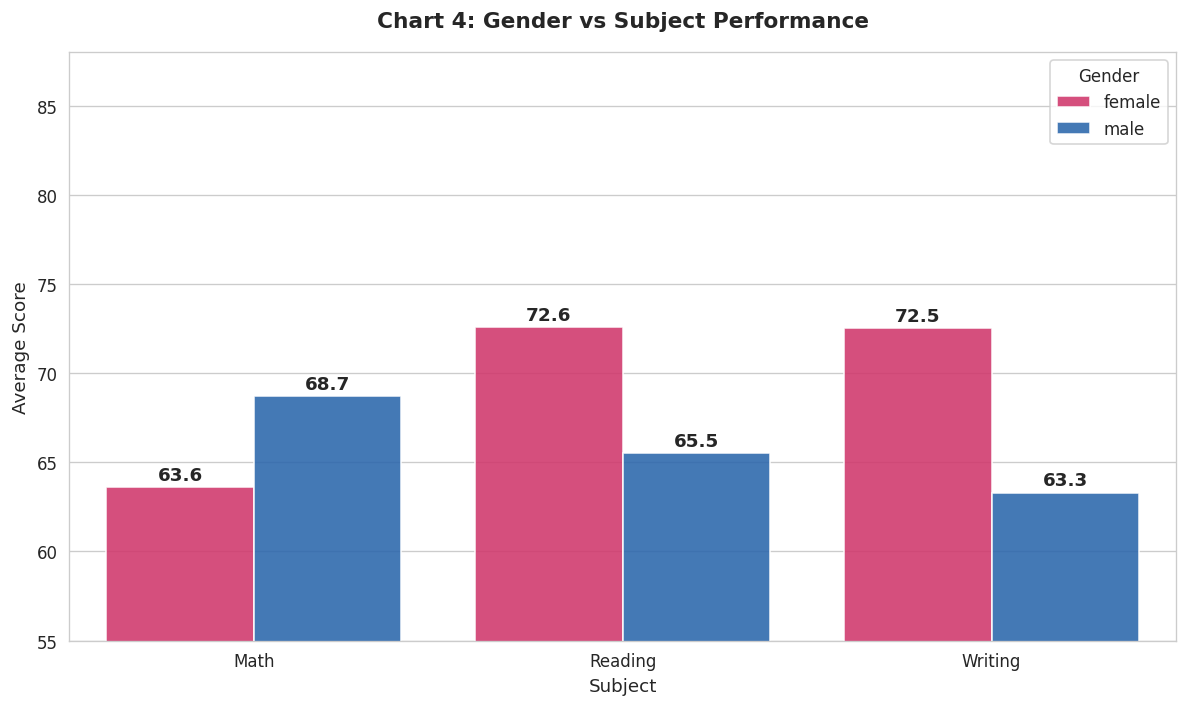

  ✅ Chart 4 done


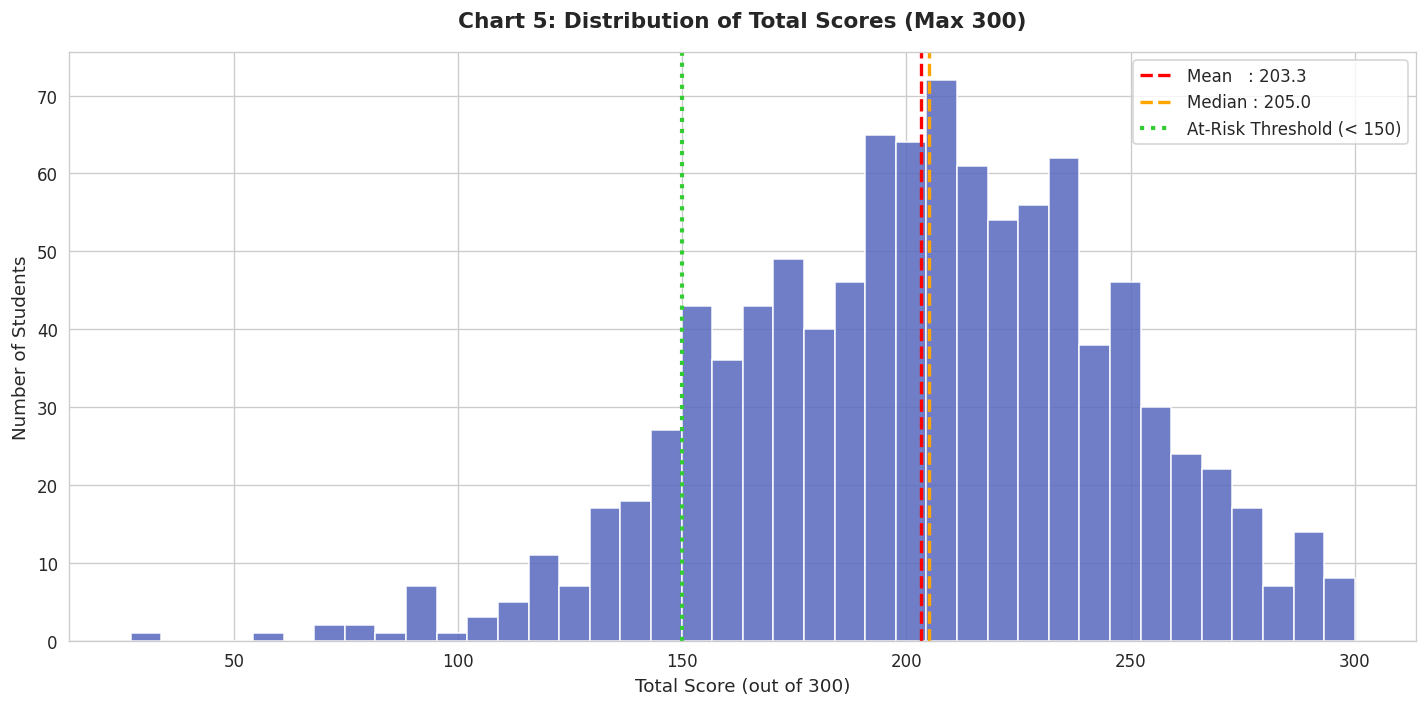

  ✅ Chart 5 done


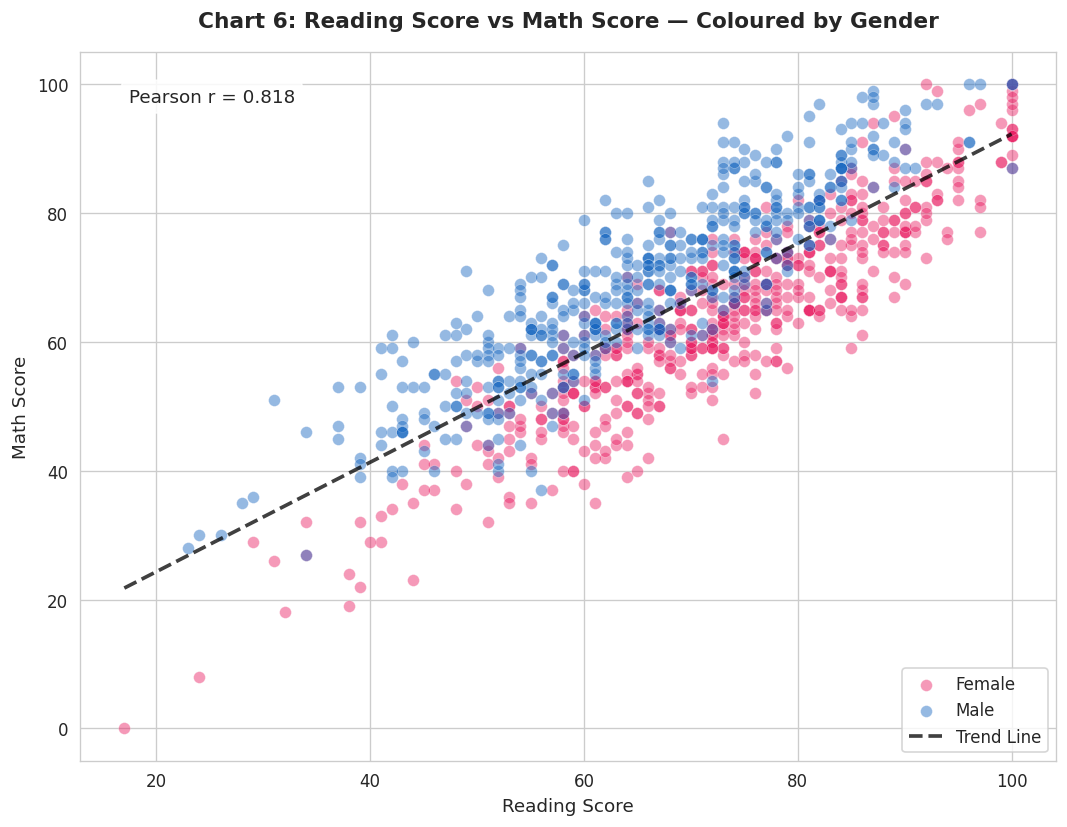

  ✅ Chart 6 done

  AT-RISK STUDENT SEGMENTATION
  Definition: scoring below 50 in ANY one subject

  Total students     : 1000
  At-risk students   : 188  (18.8%)
  Safe students      : 812  (81.2%)

  📋 By Parental Education:
                    At_Risk_Count  Total  At_Risk_Pct
parental_education                                   
some high school               46    179         25.7
high school                    49    196         25.0
some college                   38    226         16.8
associate's degree             33    222         14.9
bachelor's degree              16    118         13.6
master's degree                 6     59         10.2

  📋 By Gender:
        At_Risk_Count  Total  At_Risk_Pct
gender                                   
male               99    482         20.5
female             89    518         17.2

  📋 By Test Prep:
           At_Risk_Count  Total  At_Risk_Pct
test_prep                                   
none                 152    642         23.7
co

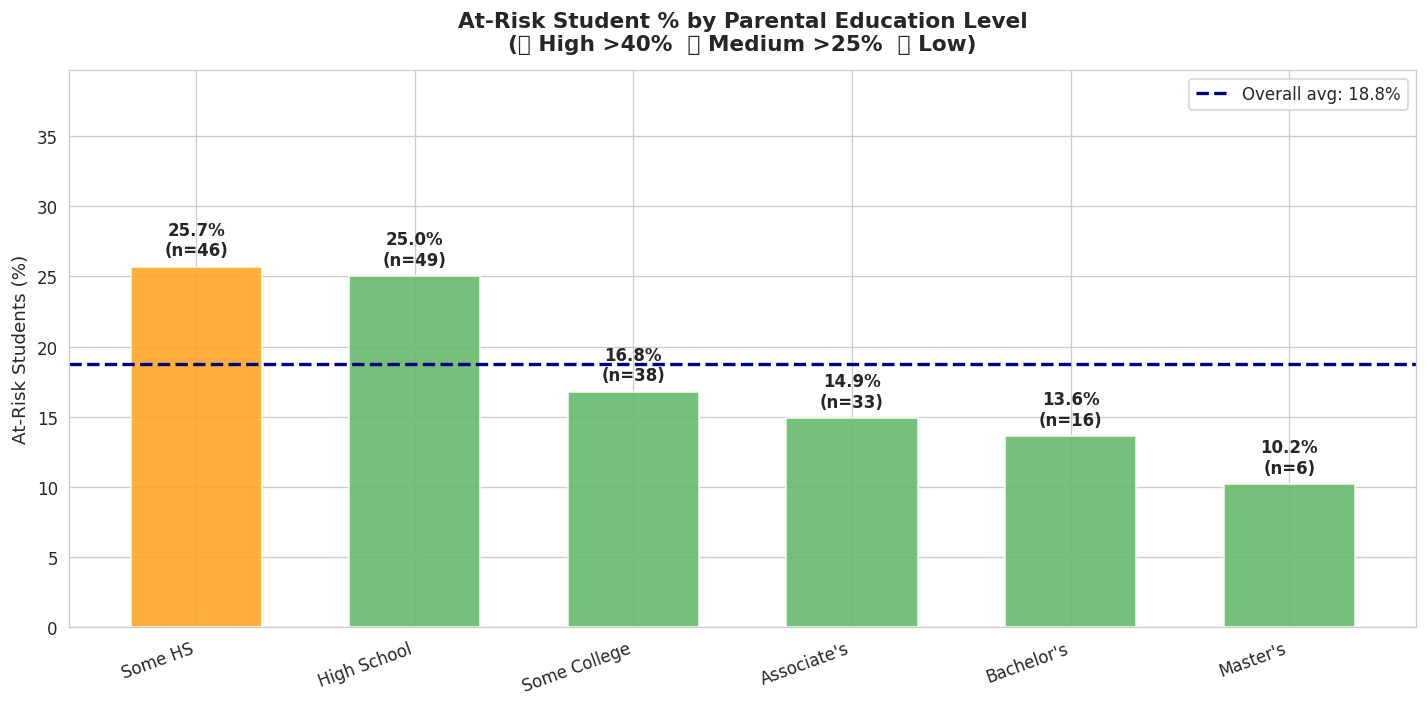


  ✅ At-risk chart done


In [2]:

import subprocess
subprocess.run(['pip', 'install', 'pandas', 'matplotlib', 'seaborn', 'numpy', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import files

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['figure.dpi']       = 120

OUTPUT_DIR = '/content/project02_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 60)
print("  ✅ All libraries loaded. Ready to go!")
print("=" * 60)


# =============================================================================
# STEP 2: LOAD & EXPLORE DATA
# =============================================================================

df = pd.read_csv('/content/StudentsPerformance.csv')

print("\n" + "=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"\n  Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n  Columns : {df.columns.tolist()}")
print(f"\n  Data Types:\n{df.dtypes}")
print(f"\n  Missing Values:\n{df.isnull().sum()}")
print(f"\n  Duplicates: {df.duplicated().sum()}")
print(f"\n  First 5 rows:")
print(df.head())

# =============================================================================
# STEP 3: DATA CLEANING
# =============================================================================

# Rename columns
df.columns = [
    'gender', 'race_ethnicity', 'parental_education',
    'lunch', 'test_prep', 'math_score',
    'reading_score', 'writing_score'
]

# Add total and average score
df['total_score']   = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = (df['total_score'] / 3).round(2)

# Remove duplicates if any
before = len(df)
df.drop_duplicates(inplace=True)
print(f"\n  Duplicates removed: {before - len(df)}")

print("\n" + "─" * 50)
print("  📋 5-LINE DATASET SUMMARY")
print("─" * 50)
print(f"  1. Total students             : {len(df)}")
print(f"  2. Gender split               : {df['gender'].value_counts().to_dict()}")
print(f"  3. Avg Math / Reading / Writing: {df['math_score'].mean():.1f} / {df['reading_score'].mean():.1f} / {df['writing_score'].mean():.1f}")
print(f"  4. Parental education levels  : {df['parental_education'].nunique()} unique categories")
print(f"  5. Test prep completion       : {df['test_prep'].value_counts().to_dict()}")
print("─" * 50)
print("  ✅ Data cleaning complete.")

# =============================================================================
# STEP 4: FACTOR ANALYSIS — 5 QUESTIONS
# =============================================================================

print("\n" + "=" * 60)
print("  FACTOR ANALYSIS — 5 QUESTIONS")
print("=" * 60)

EDU_ORDER = [
    'some high school', 'high school', 'some college',
    "associate's degree", "bachelor's degree", "master's degree"
]

# ── Q1: Parental Education vs Scores ─────────────────────────────────────
avg_by_edu = (df.groupby('parental_education')
                .agg(Math    = ('math_score',    'mean'),
                     Reading = ('reading_score', 'mean'),
                     Writing = ('writing_score', 'mean'),
                     Count   = ('math_score',    'count'))
                .reindex(EDU_ORDER)
                .round(1))

print("\n  Q1 — Average Scores by Parental Education Level:")
print(avg_by_edu.to_string())

low_math  = avg_by_edu.loc['some high school', 'Math']
high_math = avg_by_edu.loc["master's degree",  'Math']
print(f"\n  → Math score gap (some high school → master's): +{high_math - low_math:.1f} points")

# ── Q2: Test Prep vs Scores ───────────────────────────────────────────────
prep_scores = (df.groupby('test_prep')
                 .agg(Math     = ('math_score',    'mean'),
                      Reading  = ('reading_score', 'mean'),
                      Writing  = ('writing_score', 'mean'),
                      Students = ('math_score',    'count'))
                 .round(1))

print("\n  Q2 — Scores by Test Prep Completion:")
print(prep_scores.to_string())

prep_diff_math    = prep_scores.loc['completed', 'Math']    - prep_scores.loc['none', 'Math']
prep_diff_reading = prep_scores.loc['completed', 'Reading'] - prep_scores.loc['none', 'Reading']
prep_diff_writing = prep_scores.loc['completed', 'Writing'] - prep_scores.loc['none', 'Writing']
print(f"\n  → Test prep improvement: Math +{prep_diff_math:.1f} | Reading +{prep_diff_reading:.1f} | Writing +{prep_diff_writing:.1f} pts")

# ── Q3: Correlation Between Subjects ─────────────────────────────────────
corr = df[['math_score', 'reading_score', 'writing_score']].corr().round(3)

print("\n  Q3 — Correlation Matrix:")
print(corr.to_string())
print(f"\n  → Math ↔ Reading   : {corr.loc['math_score','reading_score']}")
print(f"  → Math ↔ Writing   : {corr.loc['math_score','writing_score']}")
print(f"  → Reading ↔ Writing: {corr.loc['reading_score','writing_score']}")

# ── Q4: Gender vs Subject ─────────────────────────────────────────────────
gender_scores = (df.groupby('gender')
                   .agg(Math    = ('math_score',    'mean'),
                        Reading = ('reading_score', 'mean'),
                        Writing = ('writing_score', 'mean'),
                        Count   = ('math_score',    'count'))
                   .round(1))

print("\n  Q4 — Average Scores by Gender:")
print(gender_scores.to_string())
print("\n  → Subject winners:")
for subj in ['Math', 'Reading', 'Writing']:
    winner = gender_scores[subj].idxmax()
    margin = gender_scores[subj].max() - gender_scores[subj].min()
    print(f"     {subj:10s}: {winner.upper()} leads by +{margin:.1f} pts")

# ── Q5: Total Score Distribution ─────────────────────────────────────────
print("\n  Q5 — Total Score Distribution (max = 300):")
print(df['total_score'].describe().round(1).to_string())
print(f"\n  → High performers (250+) : {(df['total_score'] >= 250).sum()} students")
print(f"  → Low scorers (below 150): {(df['total_score'] < 150).sum()} students")

print("\n  ✅ Factor analysis complete.")

# =============================================================================
# STEP 5: VISUALISATIONS — 6 CHARTS
# =============================================================================

print("\n[Generating Charts — please wait...]")

COLORS = {
    'math':    '#1976D2',
    'reading': '#388E3C',
    'writing': '#7B1FA2'
}

# ── CHART 1: Box Plot — Scores by Parental Education ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
short_labels = ["Some HS", "High\nSchool", "Some\nCollege",
                "Associate's", "Bachelor's", "Master's"]

for ax, (subj_col, color) in zip(axes, COLORS.items()):
    data_plot = [df[df['parental_education'] == edu][f'{subj_col}_score'].dropna().values
                 for edu in EDU_ORDER]
    ax.boxplot(data_plot, patch_artist=True,
               boxprops     =dict(facecolor=color, alpha=0.75),
               medianprops  =dict(color='white', linewidth=2.5),
               whiskerprops =dict(color='gray'),
               capprops     =dict(color='gray'),
               flierprops   =dict(marker='o', markerfacecolor=color, markersize=4, alpha=0.4))
    ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{subj_col.capitalize()} Score', fontsize=11)
    if ax == axes[0]:
        ax.set_ylabel('Score (0–100)', fontsize=10)
    ax.set_ylim(0, 108)

fig.suptitle('Chart 1: Score Distribution by Parental Education Level',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart1_parental_education_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 1 done")

# ── CHART 2: Grouped Bar — Test Prep Comparison ───────────────────────────
subjects_display = ['Math', 'Reading', 'Writing']
subjects_keys    = ['Math', 'Reading', 'Writing']
x     = np.arange(len(subjects_display))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
vals_comp = [prep_scores.loc['completed', s] for s in subjects_keys]
vals_none = [prep_scores.loc['none', s]      for s in subjects_keys]

bars1 = ax.bar(x - width/2, vals_comp, width, label='✅ Completed Test Prep',
               color='#43A047', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, vals_none, width, label='❌ No Test Prep',
               color='#E53935', alpha=0.88, edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(subjects_display, fontsize=12)
ax.set_ylabel('Average Score', fontsize=11)
ax.set_ylim(0, 90)
ax.set_title('Chart 2: Test Prep Completed vs Not Completed — Score Comparison',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart2_test_prep_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 2 done")

# ── CHART 3: Correlation Heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=0.75, vmax=1.0, ax=ax, mask=mask,
            square=True, linewidths=2.5,
            annot_kws={'size': 15, 'weight': 'bold'},
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})

ax.set_xticklabels(['Math', 'Reading', 'Writing'], fontsize=11)
ax.set_yticklabels(['Math', 'Reading', 'Writing'], fontsize=11, rotation=0)
ax.set_title('Chart 3: Correlation Between Math, Reading & Writing Scores',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 3 done")

# ── CHART 4: Grouped Bar — Gender vs Subject ──────────────────────────────
gender_melt = (gender_scores[['Math', 'Reading', 'Writing']]
               .reset_index()
               .melt(id_vars='gender', var_name='Subject', value_name='Avg Score'))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=gender_melt, x='Subject', y='Avg Score', hue='gender',
            palette={'female': '#E91E63', 'male': '#1565C0'},
            alpha=0.88, ax=ax, edgecolor='white')

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}',
                    (p.get_x() + p.get_width()/2, h + 0.4),
                    ha='center', fontsize=11, fontweight='bold')

ax.set_title('Chart 4: Gender vs Subject Performance',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Subject', fontsize=11)
ax.set_ylabel('Average Score', fontsize=11)
ax.set_ylim(55, 88)
ax.legend(title='Gender', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart4_gender_subject.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 4 done")

# ── CHART 5: Histogram — Total Score Distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['total_score'], bins=40, color='#5C6BC0', edgecolor='white', alpha=0.88)
ax.axvline(df['total_score'].mean(),   color='red',        linestyle='--', linewidth=2,
           label=f"Mean   : {df['total_score'].mean():.1f}")
ax.axvline(df['total_score'].median(), color='orange',     linestyle='--', linewidth=2,
           label=f"Median : {df['total_score'].median():.1f}")
ax.axvline(150, color='limegreen', linestyle=':', linewidth=2.5,
           label='At-Risk Threshold (< 150)')

ax.set_xlabel('Total Score (out of 300)', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=11)
ax.set_title('Chart 5: Distribution of Total Scores (Max 300)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart5_total_score_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 5 done")

# ── CHART 6: Scatter — Reading vs Math (by Gender) ────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_g = {'female': '#E91E63', 'male': '#1565C0'}

for g, grp in df.groupby('gender'):
    ax.scatter(grp['reading_score'], grp['math_score'],
               c=colors_g[g], alpha=0.45, s=50, label=g.capitalize(),
               edgecolors='white', linewidths=0.3)

z      = np.polyfit(df['reading_score'], df['math_score'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df['reading_score'].min(), df['reading_score'].max(), 200)
ax.plot(x_line, p_line(x_line), 'k--', linewidth=2.2, label='Trend Line', alpha=0.75, zorder=5)

r_val = df[['reading_score', 'math_score']].corr().iloc[0, 1]
ax.text(0.05, 0.93, f'Pearson r = {r_val:.3f}',
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

ax.set_xlabel('Reading Score', fontsize=11)
ax.set_ylabel('Math Score', fontsize=11)
ax.set_title('Chart 6: Reading Score vs Math Score — Coloured by Gender',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart6_scatter_reading_math.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Chart 6 done")

# =============================================================================
# STEP 6: AT-RISK STUDENT SEGMENTATION
# =============================================================================

print("\n" + "=" * 60)
print("  AT-RISK STUDENT SEGMENTATION")
print("  Definition: scoring below 50 in ANY one subject")
print("=" * 60)

df['at_risk'] = (
    (df['math_score']    < 50) |
    (df['reading_score'] < 50) |
    (df['writing_score'] < 50)
)

total_students = len(df)
at_risk_count  = int(df['at_risk'].sum())
at_risk_pct    = at_risk_count / total_students * 100

print(f"\n  Total students     : {total_students}")
print(f"  At-risk students   : {at_risk_count}  ({at_risk_pct:.1f}%)")
print(f"  Safe students      : {total_students - at_risk_count}  ({100 - at_risk_pct:.1f}%)")

def at_risk_table(col):
    return (df.groupby(col)['at_risk']
              .agg(At_Risk_Count='sum', Total='count')
              .assign(At_Risk_Pct=lambda x: (x['At_Risk_Count'] / x['Total'] * 100).round(1))
              .sort_values('At_Risk_Pct', ascending=False))

print("\n  📋 By Parental Education:")
edu_risk = at_risk_table('parental_education')
print(edu_risk.to_string())

print("\n  📋 By Gender:")
print(at_risk_table('gender').to_string())

print("\n  📋 By Test Prep:")
print(at_risk_table('test_prep').to_string())

print("\n  📋 By Lunch Type (Socioeconomic Indicator):")
print(at_risk_table('lunch').to_string())

# At-risk bar chart
atrisk_edu = at_risk_table('parental_education').reindex(EDU_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#EF5350' if p > 40 else '#FFA726' if p > 25 else '#66BB6A'
              for p in atrisk_edu['At_Risk_Pct']]
ax.bar(range(len(atrisk_edu)), atrisk_edu['At_Risk_Pct'],
       color=bar_colors, edgecolor='white', alpha=0.9, width=0.6)
ax.axhline(at_risk_pct, color='navy', linestyle='--', linewidth=2,
           label=f'Overall avg: {at_risk_pct:.1f}%')

for i, (_, row) in enumerate(atrisk_edu.iterrows()):
    ax.text(i, row['At_Risk_Pct'] + 0.8,
            f"{row['At_Risk_Pct']}%\n(n={int(row['At_Risk_Count'])})",
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(atrisk_edu)))
ax.set_xticklabels(["Some HS", "High School", "Some College",
                     "Associate's", "Bachelor's", "Master's"],
                    rotation=20, ha='right', fontsize=10)
ax.set_ylabel('At-Risk Students (%)', fontsize=11)
ax.set_ylim(0, max(atrisk_edu['At_Risk_Pct']) + 14)
ax.set_title("At-Risk Student % by Parental Education Level\n(🔴 High >40%  🟠 Medium >25%  🟢 Low)",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/at_risk_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  ✅ At-risk chart done")
